# Notebook 4 | Source Model Statistics Explorer
## Geo-INQUIRE Workshop · Messina, April 2026

This notebook browses remote ESHM20 files within a chosen dataset version scope and then analyzes a selected supported subset.

Discovery is intentionally broader than analysis: the inventory view shows directories plus supported and unsupported files under the chosen scope, while the current v1 analysis path remains limited to `asm_v12e` area-source XML files.


Reusable implementation logic lives in `notebook_support/source_model_statistics_explorer_helpers.py`.

Use that module to inspect parsing and filtering details. This notebook stays focused on analysis choices and figure construction.


In [3]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

from utils.source_model_statistics_explorer_helpers import (
    REPO_RAW_BASE,
    build_truncgr_mfd,
    closed_polygon,
    compute_bounds_from_docs,
    describe_selected_files,
    discover_scoped_inventory,
    discover_version_roots,
    filter_sources_by_region,
    load_selected_source_model_files,
    normalize_region_selection,
    parse_polygon_text,
    summarize_source_inventory,
    validate_selected_files,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 10, 'legend.fontsize': 8})
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', None)


## 1. Choose Scope, Then Choose Files

Start by listing version roots under `oq_computational/` for a repository ref. Then choose a visible `version_root` and `discovery_subpath`, inspect the discovered inventory, choose an analysis-supported family from that output, and finally select files explicitly from the supported table.

In Step 1, the next code cell uses `repo_ref` to discover candidate version roots under `oq_computational/` and stores them in `version_roots`. Expect a table with names, repository paths, version tags, and regions. Use that table to pick a valid `version_root` for the scoped discovery in Steps 2-3.

The v1 analysis path remains intentionally narrow: `asm_v12e` area-source XML files (with known blocked variants excluded).


In [4]:
# Step 1: choose a repository ref and discover version roots.
repo_ref = 'master'

version_roots = discover_version_roots(repo_ref=repo_ref)
if version_roots.empty:
    raise ValueError('No version-root candidates discovered under oq_computational/.')

print(f"Discovered version roots at ref '{repo_ref}': {len(version_roots)}")
display(version_roots[['name', 'repo_rel', 'version_tag', 'region']])


Discovered version roots at ref 'master': 3


,name,repo_rel,version_tag,region
0,oq_configuration_eshm20_v12e_region_iceland,oq_computational/oq_configuration_eshm20_v12e_region_iceland,v12e,iceland
1,oq_configuration_eshm20_v12e_region_main,oq_computational/oq_configuration_eshm20_v12e_region_main,v12e,main
2,oq_configuration_eshm20_v12e_region_swIslands,oq_computational/oq_configuration_eshm20_v12e_region_swIslands,v12e,swIslands


The next cell uses `repo_ref` from Step 1 plus your editable `version_root` and `discovery_subpath` values to discover a scoped inventory. It creates `discovery_result`, then prints scope metadata, row counts, and compact preview tables for discovered entries. Check `scope_root`, warnings, and supported-row counts to confirm you are browsing the intended part of the repository before choosing a family.


In [5]:
## Steps 2 and 3:

# ===> Step 2: choose one visible version root and a discovery subpath from the table above.
version_root = 'oq_computational/oq_configuration_eshm20_v12e_region_main'
discovery_subpath = 'source_models'  # Set '' to browse the full version root.

if version_root not in set(version_roots['repo_rel']):
    raise ValueError(
        'version_root must be one of the discovered repo_rel values. '
        f"Current value: {version_root}"
    )

# ===> Step 3: discover inventory for the selected scope and inspect what exists there.
discovery_result = discover_scoped_inventory(
    repo_ref=repo_ref,
    version_root=version_root,
    discovery_subpath=discovery_subpath,
)

scope = discovery_result['scope']
inventory = discovery_result['inventory']
supported_inventory = discovery_result['supported_inventory']
summary = discovery_result['summary']
warnings = discovery_result['warnings']

print('Current discovery scope:')
print(f"- repo_ref: {scope['repo_ref']}")
print(f"- version_root: {scope['version_root']}")
print(f"- discovery_subpath: {scope['discovery_subpath'] or '(entire version root)'}")
print(f"- scope_root: {scope['scope_root']}")
print('')
print(f"Discovered rows: {summary['n_inventory_rows']}")
print(f"Supported rows: {summary['n_supported_rows']}")
if warnings:
    print('Warnings:')
    for warning in warnings:
        print(f'- {warning}')

print('')
print('Entries visible in this scope (directories/files):')
display(summary['counts_by_entry_type'])

inventory_view_columns = [
    'relative_path',
    'entry_type',
    'extension',
    'family_dir',
    'analysis_status',
    'name',
]
inventory_view = inventory[inventory_view_columns]
preview_limit = 40

print(f"Compact inventory preview: first {min(len(inventory_view), preview_limit)} of {len(inventory_view)} rows")
display(inventory_view.head(preview_limit))
if len(inventory_view) > preview_limit:
    print('Use `inventory[inventory_view_columns]` to inspect the full discovered inventory when needed.')


Current discovery scope:
- repo_ref: master
- version_root: oq_computational/oq_configuration_eshm20_v12e_region_main
- discovery_subpath: source_models
- scope_root: oq_computational/oq_configuration_eshm20_v12e_region_main/source_models

Discovered rows: 57
Supported rows: 12

Entries visible in this scope (directories/files):


,entry_type,count
0,file,51
1,directory,6


Compact inventory preview: first 40 of 57 rows


,relative_path,entry_type,extension,family_dir,analysis_status,name
0,asm_v12e,directory,,asm_v12e,directory,asm_v12e
1,deep_v12e,directory,,deep_v12e,directory,deep_v12e
2,fsm_v09,directory,,fsm_v09,directory,fsm_v09
3,interface_v12b,directory,,interface_v12b,directory,interface_v12b
4,ssm_v09,directory,,ssm_v09,directory,ssm_v09
5,volcanic_v12e,directory,,volcanic_v12e,directory,volcanic_v12e
6,asm_v12e/asm_ver12e_winGT_fs017_hi_abgrs_maxmag_low.xml,file,.xml,asm_v12e,supported,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_low.xml
7,asm_v12e/asm_ver12e_winGT_fs017_hi_abgrs_maxmag_mid.xml,file,.xml,asm_v12e,supported,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_mid.xml
8,asm_v12e/asm_ver12e_winGT_fs017_hi_abgrs_maxmag_upp.xml,file,.xml,asm_v12e,supported,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_upp.xml
9,asm_v12e/asm_ver12e_winGT_fs017_lo_abgrs_maxmag_low.xml,file,.xml,asm_v12e,supported,asm_ver12e_winGT_fs017_lo_abgrs_maxmag_low.xml


Use `inventory[inventory_view_columns]` to inspect the full discovered inventory when needed.


The discovered scope can contain multiple model families and mixed file types. Not every discovered family is currently analyzable in this notebook.

The next cell groups the `inventory` from Steps 2-3 by `family_dir` and `analysis_status`, then builds a family-by-support breakdown table. Expect three summary views: families present, support-status totals, and a combined pivot. Use these counts to choose a family that is visible in scope and analysis-supported for the next steps.


In [6]:
# Step 4: inspect family and support-status visibility before choosing a family.
family_counts = (
    inventory.groupby('family_dir', dropna=False)
    .size()
    .rename('rows_in_scope')
    .reset_index()
    .sort_values('rows_in_scope', ascending=False)
)

support_counts = (
    inventory.groupby('analysis_status', dropna=False)
    .size()
    .rename('rows_in_scope')
    .reset_index()
    .sort_values('rows_in_scope', ascending=False)
)

family_support_breakdown = (
    inventory.pivot_table(
        index='family_dir',
        columns='analysis_status',
        values='relative_path',
        aggfunc='count',
        fill_value=0,
    )
    .reset_index()
)

status_columns = [col for col in family_support_breakdown.columns if col != 'family_dir']
family_support_breakdown['rows_in_scope'] = family_support_breakdown[status_columns].sum(axis=1)
family_support_breakdown = family_support_breakdown.sort_values('rows_in_scope', ascending=False)

print('Model families visible in this scope:')
display(family_counts)

print('Support status of discovered entries in this scope:')
display(support_counts)

print('Family/support breakdown used to choose the analysis path:')
display(family_support_breakdown)


Model families visible in this scope:


,family_dir,rows_in_scope
0,asm_v12e,14
1,deep_v12e,13
5,volcanic_v12e,13
2,fsm_v09,10
3,interface_v12b,5
4,ssm_v09,2


Support status of discovered entries in this scope:


,analysis_status,rows_in_scope
2,unsupported_family,38
1,supported,12
0,directory,6
3,unsupported_variant,1


Family/support breakdown used to choose the analysis path:


analysis_status,family_dir,directory,supported,unsupported_family,unsupported_variant,rows_in_scope
0,asm_v12e,1,12,0,1,14
1,deep_v12e,1,0,12,0,13
5,volcanic_v12e,1,0,12,0,13
2,fsm_v09,1,0,9,0,10
3,interface_v12b,1,0,4,0,5
4,ssm_v09,1,0,1,0,2


Step 5 is the family-choice validation step. Set `dataset_family` to one of the `family_dir` values reported in the Step 4 summaries.

The cell checks that your choice exists in `inventory` and prints the selected family. If it raises an error, return to the family/support tables and choose one of the discovered options.


In [7]:
# Step 5: choose the supported analysis family shown above.
dataset_family = 'asm_v12e'

available_family_dirs = sorted(inventory['family_dir'].dropna().unique())
if dataset_family not in set(available_family_dirs):
    raise ValueError(
        'dataset_family must be chosen from discovered family_dir values. '
        f"Current value: {dataset_family}. Available: {available_family_dirs}"
    )

print(f"Chosen analysis family: {dataset_family}")
print('The current v1 analysis path continues with supported asm_v12e XML files.')


Chosen analysis family: asm_v12e
The current v1 analysis path continues with supported asm_v12e XML files.


The next cell uses `supported_inventory` and the chosen `dataset_family` to build the analysis-supported file list for that family.

Expect a table (`supported_selection_table`) with `selection_id`, short filename, and exact `repo_rel` path. Copy `repo_rel` values from this table into the Step 7 `selected_files` list.


In [8]:
# Step 6: inspect files that are analysis-supported for the chosen family.
supported_family_inventory = (
    supported_inventory[supported_inventory['family_dir'] == dataset_family]
    .copy()
    .sort_values('repo_rel')
)

if supported_family_inventory.empty:
    raise ValueError(
        f'No analysis-supported rows found for dataset_family={dataset_family!r} in the selected scope.'
    )

supported_selection_table = supported_family_inventory[['repo_rel']].copy().reset_index(drop=True)
supported_selection_table.insert(0, 'selection_id', supported_selection_table.index + 1)
supported_selection_table['file'] = supported_selection_table['repo_rel'].str.split('/').str[-1]
supported_selection_table = supported_selection_table[['selection_id', 'file', 'repo_rel']]

print(f"Supported files for dataset_family='{dataset_family}': {len(supported_selection_table)}")
print('Copy repo_rel values from the table below into selected_files in the next cell.')
with pd.option_context('display.max_colwidth', None, 'display.width', 240):
    display(supported_selection_table)


Supported files for dataset_family='asm_v12e': 12
Copy repo_rel values from the table below into selected_files in the next cell.


,selection_id,file,repo_rel
0,1,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_low.xml,oq_computational/oq_configuration_eshm20_v12e_region_main/source_models/asm_v12e/asm_ver12e_winGT_fs017_hi_abgrs_maxmag_low.xml
1,2,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_mid.xml,oq_computational/oq_configuration_eshm20_v12e_region_main/source_models/asm_v12e/asm_ver12e_winGT_fs017_hi_abgrs_maxmag_mid.xml
2,3,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_upp.xml,oq_computational/oq_configuration_eshm20_v12e_region_main/source_models/asm_v12e/asm_ver12e_winGT_fs017_hi_abgrs_maxmag_upp.xml
3,4,asm_ver12e_winGT_fs017_lo_abgrs_maxmag_low.xml,oq_computational/oq_configuration_eshm20_v12e_region_main/source_models/asm_v12e/asm_ver12e_winGT_fs017_lo_abgrs_maxmag_low.xml
4,5,asm_ver12e_winGT_fs017_lo_abgrs_maxmag_mid.xml,oq_computational/oq_configuration_eshm20_v12e_region_main/source_models/asm_v12e/asm_ver12e_winGT_fs017_lo_abgrs_maxmag_mid.xml
5,6,asm_ver12e_winGT_fs017_lo_abgrs_maxmag_upp.xml,oq_computational/oq_configuration_eshm20_v12e_region_main/source_models/asm_v12e/asm_ver12e_winGT_fs017_lo_abgrs_maxmag_upp.xml
6,7,asm_ver12e_winGT_fs017_mid_abgrs_maxmag_low.xml,oq_computational/oq_configuration_eshm20_v12e_region_main/source_models/asm_v12e/asm_ver12e_winGT_fs017_mid_abgrs_maxmag_low.xml
7,8,asm_ver12e_winGT_fs017_mid_abgrs_maxmag_mid.xml,oq_computational/oq_configuration_eshm20_v12e_region_main/source_models/asm_v12e/asm_ver12e_winGT_fs017_mid_abgrs_maxmag_mid.xml
8,9,asm_ver12e_winGT_fs017_mid_abgrs_maxmag_upp.xml,oq_computational/oq_configuration_eshm20_v12e_region_main/source_models/asm_v12e/asm_ver12e_winGT_fs017_mid_abgrs_maxmag_upp.xml
9,10,asm_ver12e_winGT_fs017_pareto_abgrs_cornermag_low.xml,oq_computational/oq_configuration_eshm20_v12e_region_main/source_models/asm_v12e/asm_ver12e_winGT_fs017_pareto_abgrs_cornermag_low.xml


### Step 7. Choose Files In The Next Cell

This is the main manual selection point. It uses `supported_family_inventory` and `dataset_family` from Steps 5-6.

Paste exact `repo_rel` values into `selected_files` from the supported-file table above. The cell validates those paths and then prints a confirmation table (`selected_file_table`) that defines the exact files used by all downstream loading, maps, and statistics.


In [9]:
# Step 7: explicitly choose repo_rel values from the table above.
selected_files = [
    'oq_computational/oq_configuration_eshm20_v12e_region_main/source_models/asm_v12e/asm_ver12e_winGT_fs017_hi_abgrs_maxmag_low.xml',
    'oq_computational/oq_configuration_eshm20_v12e_region_main/source_models/asm_v12e/asm_ver12e_winGT_fs017_hi_abgrs_maxmag_mid.xml',
    'oq_computational/oq_configuration_eshm20_v12e_region_main/source_models/asm_v12e/asm_ver12e_winGT_fs017_hi_abgrs_maxmag_upp.xml',
]

selected_files = validate_selected_files(selected_files=selected_files, dataset_family=dataset_family)

supported_repo_rels = set(supported_family_inventory['repo_rel'])
out_of_scope = [repo_rel for repo_rel in selected_files if repo_rel not in supported_repo_rels]
if out_of_scope:
    raise ValueError(
        'selected_files must be chosen from supported files for the chosen dataset_family:\n - '
        + '\n - '.join(out_of_scope)
    )

selected_file_table = describe_selected_files(selected_files=selected_files, dataset_family=dataset_family)

print('')
print(f'Remote raw base: {REPO_RAW_BASE}')
print(f'Selected file count: {len(selected_files)}')
print('Validated selected files:')
display(selected_file_table[['file', 'repo_rel', 'dataset_family', 'parser_path']])



Remote raw base: https://gitlab.seismo.ethz.ch/efehr/eshm20/-/raw/master
Selected file count: 3
Validated selected files:


,file,repo_rel,dataset_family,parser_path
0,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_low.xml,oq_computational/oq_configuration_eshm20_v12e_region_main/source_models/asm_v12e/asm_ver12e_winGT_fs017_hi_abgrs_maxmag_low.xml,asm_v12e,asm_v12e_area_source_xml_v1
1,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_mid.xml,oq_computational/oq_configuration_eshm20_v12e_region_main/source_models/asm_v12e/asm_ver12e_winGT_fs017_hi_abgrs_maxmag_mid.xml,asm_v12e,asm_v12e_area_source_xml_v1
2,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_upp.xml,oq_computational/oq_configuration_eshm20_v12e_region_main/source_models/asm_v12e/asm_ver12e_winGT_fs017_hi_abgrs_maxmag_upp.xml,asm_v12e,asm_v12e_area_source_xml_v1


## 2. First visual check: where are the selected sources located?

We have now selected and validated the files to analyze. Before comparing statistics, it is helpful to inspect where their earthquake source zones are located geographically.

In this notebook, the **domain** means the full geographic area covered by the selected files before any regional filtering.

The next code cell uses `selected_files` to load parsed documents (`parsed_docs`), assigns one label/color per file, and draws all source polygons on one map. Expect a whole-domain figure with a legend keyed by file name and map limits computed from all loaded polygons. Use this as a spatial sanity check before applying any region filter.


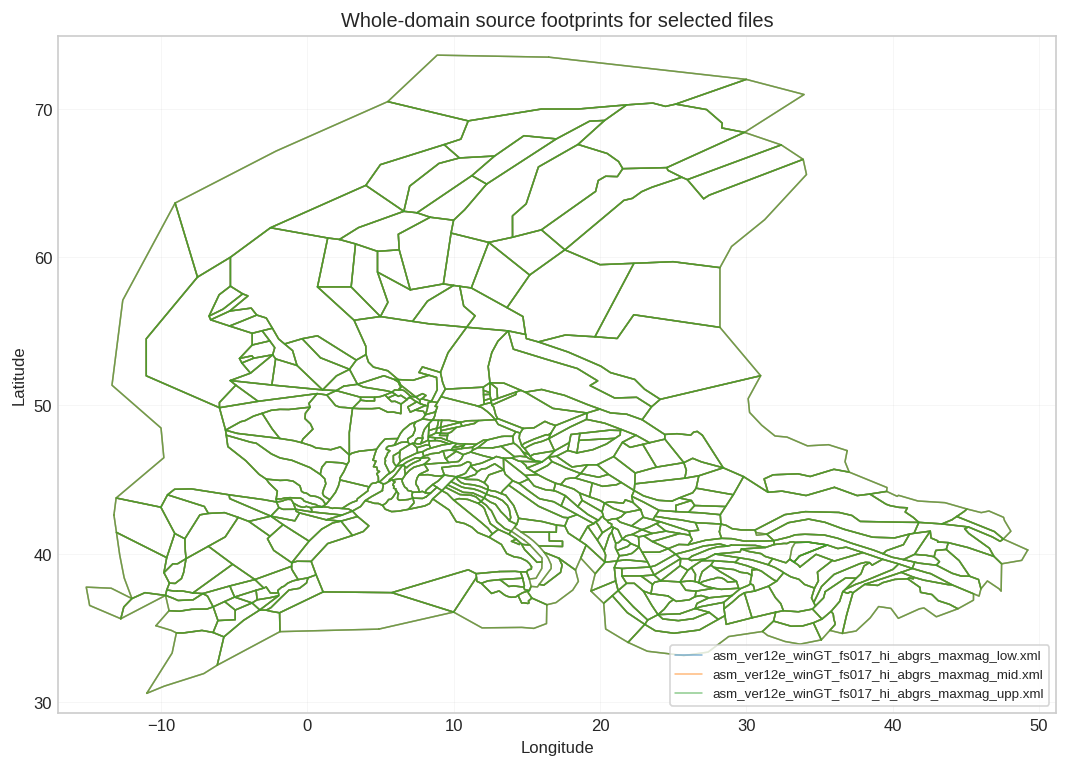

In [10]:
# Create short file labels so legends and tables stay readable.
file_labels = {repo_rel: repo_rel.split('/')[-1] for repo_rel in selected_files}
# Reuse one consistent color per file across all later figures.
color_cycle = plt.get_cmap('tab10').colors
file_colors = {repo_rel: color_cycle[i % len(color_cycle)] for i, repo_rel in enumerate(selected_files)}

# Load the selected remote source-model files from the repository raw base.
parsed_docs = load_selected_source_model_files(
    selected_files=selected_files,
    dataset_family=dataset_family,
    repo_raw_base=REPO_RAW_BASE,
)

whole_map_figsize = (9.0, 6.5)
whole_map_linewidth = 0.9
whole_map_alpha = 0.55

fig, ax = plt.subplots(figsize=whole_map_figsize)

# Draw every source polygon from each selected file for geographic orientation.
for repo_rel in selected_files:
    first = True
    for source in parsed_docs[repo_rel]['sources']:
        polygon = closed_polygon(source['polygon_lonlat'])
        if polygon is None:
            continue
        xs = [point[0] for point in polygon]
        ys = [point[1] for point in polygon]
        ax.plot(
            xs,
            ys,
            color=file_colors[repo_rel],
            linewidth=whole_map_linewidth,
            alpha=whole_map_alpha,
            label=file_labels[repo_rel] if first else None,
        )
        first = False

# Set map limits from all loaded files so the full domain is visible.
bounds = compute_bounds_from_docs(parsed_docs)
if bounds is not None:
    min_lon, max_lon, min_lat, max_lat = bounds
    pad_lon = max(0.3, 0.03 * (max_lon - min_lon))
    pad_lat = max(0.3, 0.03 * (max_lat - min_lat))
    ax.set_xlim(min_lon - pad_lon, max_lon + pad_lon)
    ax.set_ylim(min_lat - pad_lat, max_lat + pad_lat)

# This first map is a spatial orientation check, not a rate comparison.
ax.set_title('Whole-domain source footprints for selected files')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linewidth=0.35, alpha=0.3)
ax.legend(loc='best', frameon=True)
plt.tight_layout()


## 3. What is inside each file?

We have seen where the sources are located. We now summarize the contents of each selected file before focusing on a smaller region.

The next table gives a compact inventory of source types found in each file.

Key columns:
- **n_area_sources**: number of area-source polygons
- **n_trunc_gr**: number of sources using truncated Gutenberg-Richter behaviour
- **n_incremental**: number of sources defined directly with incremental rates

This helps us understand whether files are similar in structure before comparing rates.


In [11]:
# Summarize the main source-model contents of each selected file before region filtering.
inventory_summary = summarize_source_inventory(parsed_docs)
display(inventory_summary[['file', 'n_area_sources', 'n_trunc_gr', 'n_incremental']])


,file,n_area_sources,n_trunc_gr,n_incremental
0,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_low.xml,375,375,0
1,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_mid.xml,375,375,0
2,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_upp.xml,375,375,0


## 4. What changes inside a selected region?

So far we have worked with the full domain. We now narrow the analysis to a user-defined region.

A **region filter** keeps only sources that fall inside the chosen area. It changes source membership, but it does **not** modify the rates of the retained sources.

In the next cell, you only define `region_selection`; filtering happens in the cell after that.

Main options:
- **whole**: keep all sources
- **circle**: keep sources inside a circle defined by center latitude, longitude, and radius

The printed dictionary is a quick check that your region settings are correct before generating filtered tables and maps.


In [12]:
# Editable region selection state (main v1 modes: 'whole' and 'circle').
region_selection = {
    'region_mode': 'circle',
    'circle_lat': 45.0,
    'circle_lon': 12.0,
    'circle_radius_km': 300.0,
}

# Advanced hook (optional): polygon mode is available but not the main v1 path.
# region_selection = {
#     'region_mode': 'polygon',
#     'polygon_text': '11.0,44.0; 15.0,44.0; 15.0,47.0; 11.0,47.0',
# }


print('Current region selection state:')
print(region_selection)
print('')


Current region selection state:
{'region_mode': 'circle', 'circle_lat': 45.0, 'circle_lon': 12.0, 'circle_radius_km': 300.0}



The next cell uses `parsed_docs`, `selected_files`, `file_colors`, and your `region_selection` to create `filtered_docs` and `filter_summary`.

You should see a per-file retention table and a preview map where grey outlines show all source polygons while colored polygons show retained sources inside the selected region. Use these outputs to verify that filtering keeps the intended spatial subset before moving on to rate comparisons.


,file,sources_before,sources_after_filter,sources_removed,pct_kept
0,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_low.xml,375,48,327,12.8
1,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_mid.xml,375,48,327,12.8
2,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_upp.xml,375,48,327,12.8


Filtering selects sources only; it does not modify source rates.


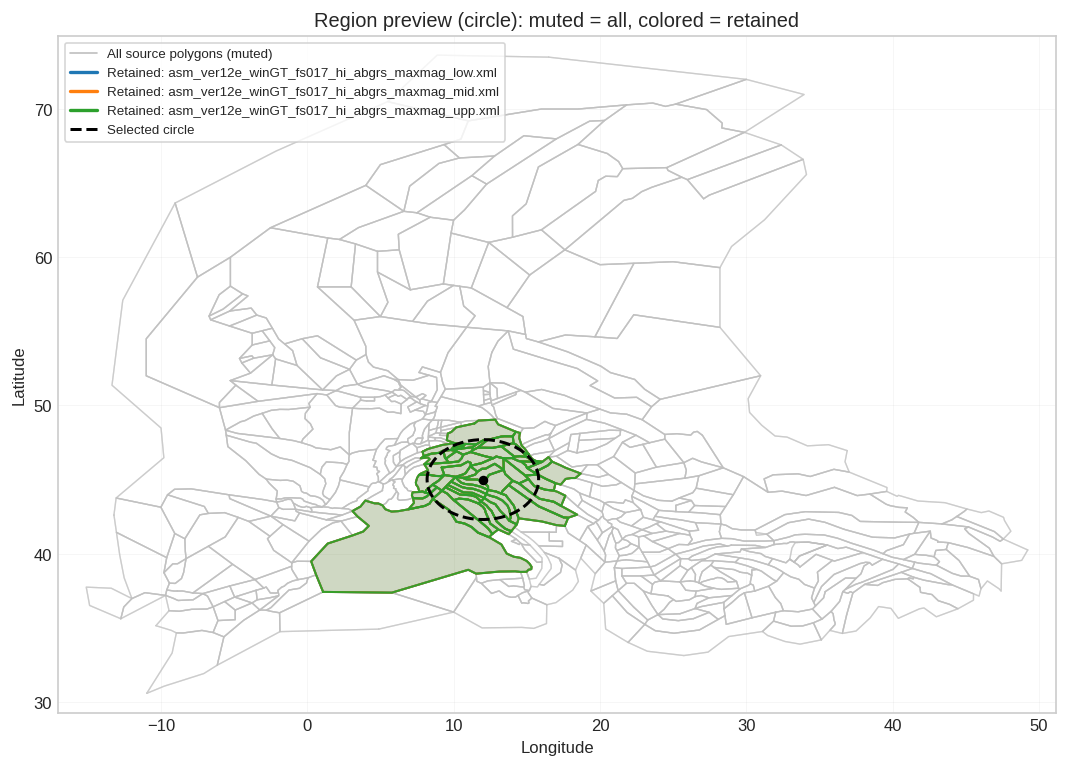

In [13]:
# Convert user input into a standard internal region-selection format.
region_selection = normalize_region_selection(region_selection)
# Keep only sources that fall inside the chosen region.
filtered_docs, filter_summary = filter_sources_by_region(parsed_docs, region_selection)

display(filter_summary[['file', 'sources_before', 'sources_after_filter', 'sources_removed', 'pct_kept']])
print('Filtering selects sources only; it does not modify source rates.')

region_map_figsize = (9.0, 6.5)
muted_linewidth = 0.8
retained_linewidth = 1.2
retained_fill_alpha = 0.12

fig, ax = plt.subplots(figsize=region_map_figsize)

# First draw all source polygons in grey to show full-domain context.
for doc in parsed_docs.values():
    for source in doc['sources']:
        polygon = closed_polygon(source['polygon_lonlat'])
        if polygon is None:
            continue
        xs = [point[0] for point in polygon]
        ys = [point[1] for point in polygon]
        ax.plot(xs, ys, color='0.75', linewidth=muted_linewidth, alpha=0.4)

# Then highlight only retained sources using each file's assigned color.
for repo_rel in selected_files:
    for source in filtered_docs[repo_rel]['sources']:
        polygon = closed_polygon(source['polygon_lonlat'])
        if polygon is None:
            continue
        xs = [point[0] for point in polygon]
        ys = [point[1] for point in polygon]
        ax.fill(xs, ys, color=file_colors[repo_rel], alpha=retained_fill_alpha)
        ax.plot(xs, ys, color=file_colors[repo_rel], linewidth=retained_linewidth, alpha=0.95)

# Draw the selected region boundary so retained sources can be interpreted spatially.
if region_selection['region_mode'] == 'circle':
    lat0 = region_selection['circle_lat']
    lon0 = region_selection['circle_lon']
    radius_km = region_selection['circle_radius_km']
    km_per_deg_lat = 111.32
    km_per_deg_lon = 111.32 * np.cos(np.radians(lat0))
    dlon = radius_km / max(km_per_deg_lon, 1e-6)
    dlat = radius_km / km_per_deg_lat
    theta = np.linspace(0.0, 2.0 * np.pi, 240)
    ax.plot(lon0 + dlon * np.cos(theta), lat0 + dlat * np.sin(theta), color='black', linestyle='--', linewidth=1.8)
    ax.scatter([lon0], [lat0], color='black', s=22, zorder=5)

if region_selection['region_mode'] == 'polygon':
    region_poly = closed_polygon(parse_polygon_text(region_selection['polygon_text']))
    if region_poly is not None:
        ax.plot([p[0] for p in region_poly], [p[1] for p in region_poly], color='black', linestyle='--', linewidth=1.8)

bounds = compute_bounds_from_docs(parsed_docs)
if bounds is not None:
    min_lon, max_lon, min_lat, max_lat = bounds
    pad_lon = max(0.3, 0.03 * (max_lon - min_lon))
    pad_lat = max(0.3, 0.03 * (max_lat - min_lat))
    ax.set_xlim(min_lon - pad_lon, max_lon + pad_lon)
    ax.set_ylim(min_lat - pad_lat, max_lat + pad_lat)

legend_handles = [Line2D([0], [0], color='0.75', lw=1.0, label='All source polygons (muted)')]
for repo_rel in selected_files:
    legend_handles.append(Line2D([0], [0], color=file_colors[repo_rel], lw=2.0, label=f"Retained: {file_labels[repo_rel]}"))
if region_selection['region_mode'] == 'circle':
    legend_handles.append(Line2D([0], [0], color='black', lw=1.8, linestyle='--', label='Selected circle'))

ax.set_title(f"Region preview ({region_selection['region_mode']}): muted = all, colored = retained")
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linewidth=0.35, alpha=0.3)
ax.legend(handles=legend_handles, loc='best', frameon=True)
plt.tight_layout()


## 5. Scientific walkthrough after region filtering

We now analyze the filtered source set in a fixed order.

1. What remains after filtering?  
2. How much seismicity is present?  
3. How is that seismicity distributed across magnitude?  
4. Which source properties help explain the differences?

This order mirrors a typical research workflow: first check support, then compare rates, then interpret why differences appear.


### What remains after filtering?

The next cell builds truncated-GR MFD inputs from `filtered_docs` and merges them with `filter_summary` from the region-filter step.

It outputs a retained-baseline table with per-file source counts before/after filtering and `n_trunc_gr_after_filter`. Use this as context for the next tables and plots so rate differences are interpreted alongside retained source support.


In [14]:
mfd_bin_width = 0.1
mfd_bundle = build_truncgr_mfd(filtered_docs, bin_width=mfd_bin_width)
trunc_table = mfd_bundle['trunc_table'].copy()

retained_trunc_counts = (
    trunc_table.groupby('repo_rel').size().rename('n_trunc_gr_after_filter')
    if not trunc_table.empty
    else pd.Series(dtype='int64', name='n_trunc_gr_after_filter')
)

# Build a compact retained-inventory baseline table before rate comparisons begin.
retained_baseline = (
    pd.DataFrame({'repo_rel': selected_files})
    .merge(
        filter_summary[['repo_rel', 'sources_before', 'sources_after_filter', 'pct_kept']],
        on='repo_rel',
        how='left',
    )
    .merge(retained_trunc_counts.reset_index(), on='repo_rel', how='left')
)

retained_baseline['file'] = [file_labels[repo_rel] for repo_rel in retained_baseline['repo_rel']]
retained_baseline['n_trunc_gr_after_filter'] = retained_baseline['n_trunc_gr_after_filter'].fillna(0).astype(int)
retained_baseline['pct_kept'] = retained_baseline['pct_kept'].round(1)

display(
    retained_baseline[
        ['file', 'sources_before', 'sources_after_filter', 'pct_kept', 'n_trunc_gr_after_filter']
    ]
)



,file,sources_before,sources_after_filter,pct_kept,n_trunc_gr_after_filter
0,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_low.xml,375,48,12.8,48
1,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_mid.xml,375,48,12.8,48
2,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_upp.xml,375,48,12.8,48


### How much seismicity is present at key magnitudes?

This cell uses `mfd_bundle`, `trunc_table`, and `selected_files` to compute comparable cumulative rates at magnitudes shared by all selected files.

It outputs a compact threshold table (for example `N(M >= 5.0)`) in scientific notation. Read it as a quick per-file comparison at key magnitudes before examining full MFD curves.


In [15]:
if trunc_table.empty:
    print('No truncated-GR sources are available under the current selection.')
else:
    per_file_range = trunc_table.groupby('repo_rel').agg(
        min_mag=('minMag', 'min'),
        max_mag=('maxMag', 'max'),
    )
    common_min = float(np.ceil(per_file_range['min_mag'].max() / mfd_bin_width) * mfd_bin_width)
    common_max = float(np.floor(per_file_range['max_mag'].min() / mfd_bin_width) * mfd_bin_width)

    # Choose thresholds shared by all files, then extract comparable cumulative exceedance rates.
    preferred_thresholds = [5.0, 6.0, 7.0]
    thresholds = [m for m in preferred_thresholds if common_min <= m <= common_max]

    if len(thresholds) < 2:
        if common_max > common_min:
            thresholds = sorted({round(float(v), 1) for v in np.linspace(common_min, common_max, num=3)})
        else:
            thresholds = [round(common_min, 1)]

    thresholds = thresholds[:3]
    mag_starts = np.asarray(mfd_bundle['mag_bin_starts'], dtype=float)

    threshold_rows = []
    for repo_rel in selected_files:
        stats = mfd_bundle['per_file'].get(repo_rel, {})
        cumulative = np.asarray(stats.get('cumulative', np.zeros_like(mag_starts)), dtype=float)
        row = {'file': file_labels[repo_rel]}

        for threshold in thresholds:
            idx = int(np.searchsorted(mag_starts, threshold, side='left'))
            rate = float(cumulative[idx]) if idx < cumulative.size else 0.0
            row[f'N(M >= {threshold:.1f})'] = rate

        threshold_rows.append(row)

    threshold_table = pd.DataFrame(threshold_rows)
    for col in threshold_table.columns[1:]:
        threshold_table[col] = threshold_table[col].map(lambda value: f'{value:.3e}')

    display(threshold_table)



,file,N(M >= 5.0),N(M >= 6.0),N(M >= 7.0)
0,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_low.xml,8.098e-01,7.705e-02,1.766e-03
1,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_mid.xml,8.178e-01,8.506e-02,4.523e-03
2,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_upp.xml,8.218e-01,8.914e-02,7.254e-03


### How is seismicity distributed across magnitude?

The next cell reuses `mfd_bundle`, `selected_files`, and `file_colors` to plot full cumulative and incremental MFD curves on one shared magnitude grid.

Expect two aligned panels with consistent colors and a legend that includes retained-source counts. Interpret cumulative curves for overall level and high-magnitude tail, and incremental curves for where each file concentrates rate by bin.


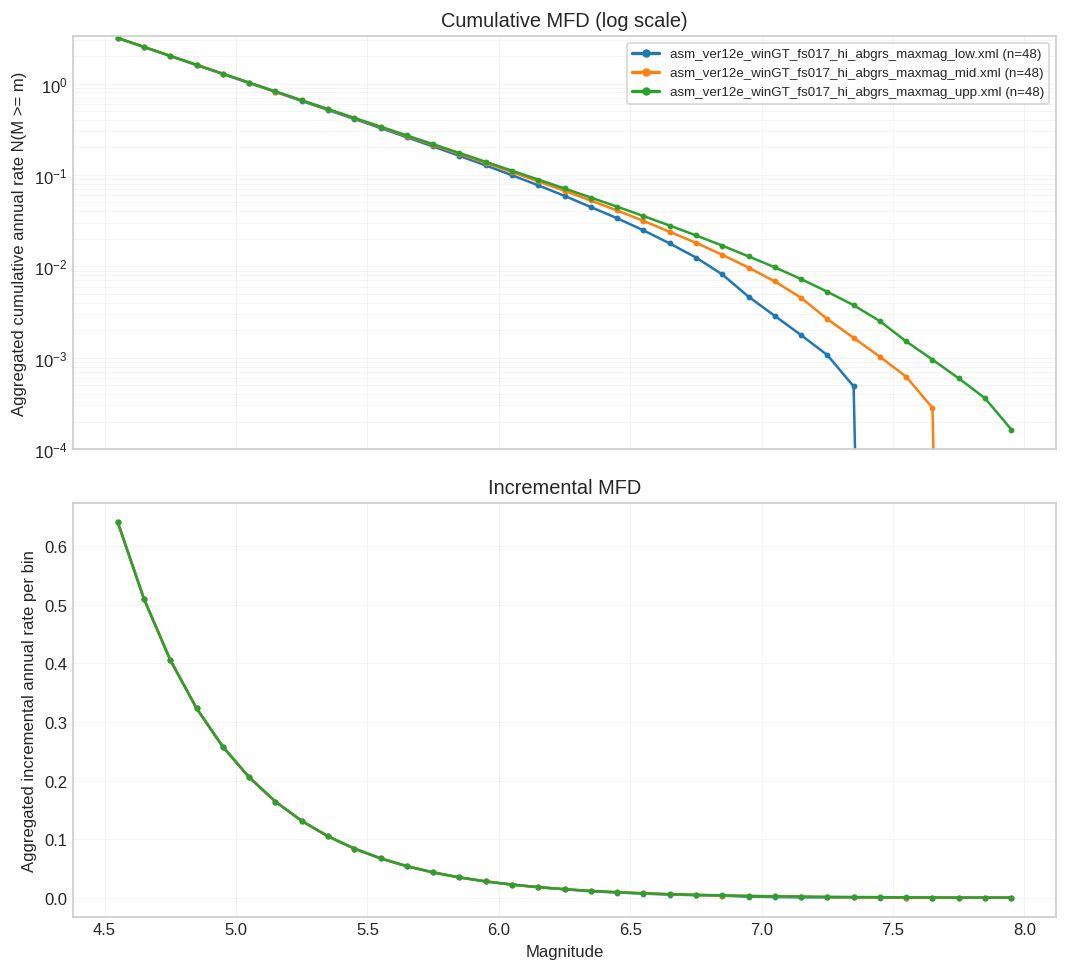

In [16]:
mfd_figsize = (9.0, 8.2)
mfd_marker_size = 2.5
mfd_linewidth = 1.5

if trunc_table.empty:
    print('No truncated-GR sources are available under the current selection.')
else:
    # Use one shared magnitude-bin grid so every file is compared on the same x-axis support.
    mag_mid = mfd_bundle['mag_bin_starts'] + 0.5 * mfd_bundle['bin_width']

    fig, axes = plt.subplots(2, 1, figsize=mfd_figsize, sharex=True)
    legend_handles = []

    for repo_rel in selected_files:
        stats = mfd_bundle['per_file'].get(repo_rel, {})
        n_sources = int(stats.get('n_sources', 0))

        cumulative_raw = np.asarray(stats.get('cumulative', np.zeros_like(mag_mid)), dtype=float)
        incremental_raw = np.asarray(stats.get('incremental', np.zeros_like(mag_mid)), dtype=float)

        cumulative = np.where(cumulative_raw > 0.0, cumulative_raw, np.nan)
        incremental = np.where(incremental_raw >= 0.0, incremental_raw, np.nan)

        # Upper panel: cumulative exceedance rates N(M >= m).
        axes[0].plot(
            mag_mid,
            cumulative,
            marker='o',
            markersize=mfd_marker_size,
            linewidth=mfd_linewidth,
            color=file_colors[repo_rel],
        )
        # Lower panel: incremental rates per magnitude bin.
        axes[1].plot(
            mag_mid,
            incremental,
            marker='o',
            markersize=mfd_marker_size,
            linewidth=mfd_linewidth,
            color=file_colors[repo_rel],
        )

        # Shared colors make each file traceable across both panels.
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color=file_colors[repo_rel],
                lw=2.0,
                marker='o',
                markersize=4,
                label=f"{file_labels[repo_rel]} (n={n_sources})",
            )
        )

    axes[0].set_ylim(bottom=1e-4)
    axes[0].set_yscale('log')
    axes[0].set_ylabel('Aggregated cumulative annual rate N(M >= m)')
    axes[0].set_title('Cumulative MFD (log scale)')
    axes[0].grid(True, which='both', linewidth=0.35, alpha=0.35)

    axes[1].set_ylabel('Aggregated incremental annual rate per bin')
    axes[1].set_xlabel('Magnitude')
    axes[1].set_title('Incremental MFD')
    axes[1].grid(True, which='both', linewidth=0.35, alpha=0.35)

    axes[0].legend(handles=legend_handles, loc='best', frameon=True)
    plt.tight_layout()



### What explains the differences between files?

This cell uses `trunc_table` and `mfd_bundle` after filtering to produce two interpretation aids.

First, it prints a per-file parameter summary table (median `aValue`, `bValue`, and magnitude limits). Then it plots a capability curve showing how many retained sources still satisfy `maxMag >= m` across magnitude. Use both outputs to explain patterns seen in the MFD comparisons.


,file,median_aValue,median_bValue,median_minMag,median_maxMag,min_maxMag,max_maxMag
0,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_low.xml,2.995,1.032,4.5,6.9,6.3,7.4
1,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_mid.xml,2.995,1.032,4.5,7.2,6.6,7.7
2,asm_ver12e_winGT_fs017_hi_abgrs_maxmag_upp.xml,2.995,1.032,4.5,7.5,6.9,8.0


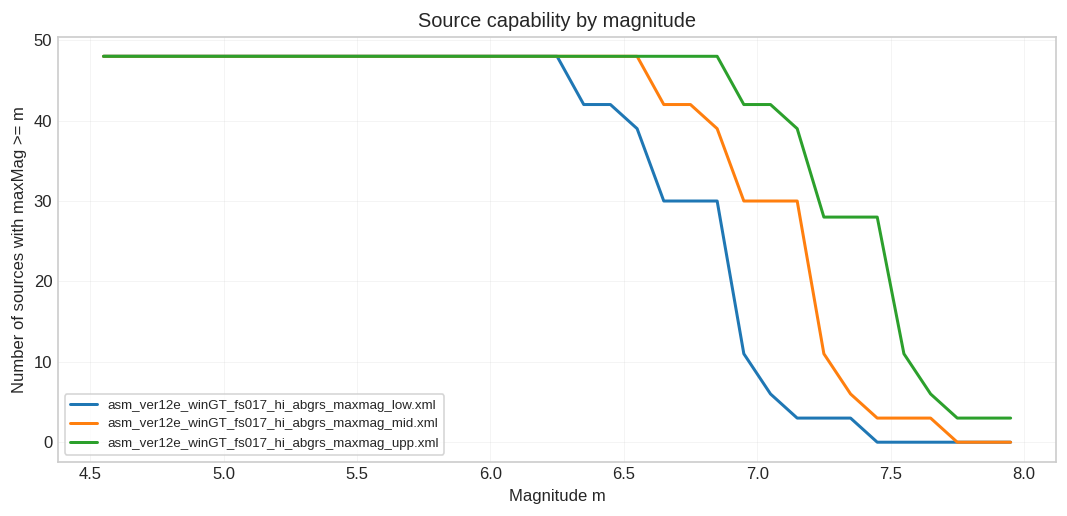

In [17]:
capability_figsize = (9.0, 4.4)

if trunc_table.empty:
    print('No truncated-GR sources are available under the current selection.')
else:
    # Summarize representative source parameters per file to support interpretation.
    param_grouped = (
        trunc_table.groupby('repo_rel')
        .agg(
            median_aValue=('aValue', 'median'),
            median_bValue=('bValue', 'median'),
            median_minMag=('minMag', 'median'),
            median_maxMag=('maxMag', 'median'),
            min_maxMag=('maxMag', 'min'),
            max_maxMag=('maxMag', 'max'),
        )
    )

    param_summary = pd.DataFrame(index=selected_files).join(param_grouped)
    param_summary.insert(0, 'file', [file_labels[repo_rel] for repo_rel in param_summary.index])

    for col in [
        'median_aValue',
        'median_bValue',
        'median_minMag',
        'median_maxMag',
        'min_maxMag',
        'max_maxMag',
    ]:
        param_summary[col] = param_summary[col].round(3)

    display(param_summary.reset_index(drop=True))

    capability_mag = np.asarray(mfd_bundle['mag_bin_starts'] + 0.5 * mfd_bundle['bin_width'], dtype=float)

    fig, ax = plt.subplots(figsize=capability_figsize)
    for repo_rel in selected_files:
        max_mags = trunc_table.loc[trunc_table['repo_rel'] == repo_rel, 'maxMag'].dropna().to_numpy()
        if max_mags.size == 0:
            continue

        # Count how many retained sources remain capable above each magnitude.
        capability_counts = np.array([(max_mags >= mag).sum() for mag in capability_mag], dtype=float)
        ax.plot(
            capability_mag,
            capability_counts,
            color=file_colors[repo_rel],
            linewidth=1.8,
            label=file_labels[repo_rel],
        )

    # This layer helps explain differences observed in the MFD comparison plots.
    ax.set_xlabel('Magnitude m')
    ax.set_ylabel('Number of sources with maxMag >= m')
    ax.set_title('Source capability by magnitude')
    ax.grid(True, linewidth=0.35, alpha=0.35)
    ax.legend(loc='best', frameon=True)
    plt.tight_layout()



## 6. Suggested exercises

If you would like to practise with the notebook, here are a few simple follow-up tasks you can try on your own.

- Change the selected files and rerun the notebook from the file-selection step downward. Note which tables and figures change and which stay the same.
- Keep the same files, but change the region filter. For example, try a smaller circle, a larger circle, or move the circle to a different location.
- Run the notebook once with a single file and once with several files. Compare how the tables, maps, and MFD plots are presented in each case.
- Compare the cumulative and incremental MFD plots for the same file set. Describe what is easier to notice in each view.
- Change one notebook setting at a time, such as the selected files or the region definition, and observe which later outputs respond to that change.
- Go back to the supported-file table and choose a different combination of files from the same family. Then rerun the analysis and compare the resulting maps and statistics.

These exercises are meant to help you become comfortable with the notebook workflow by changing one input at a time and observing how the outputs respond.
